# Introdução 

1. O dataset escolhido para o trabalho foi o Global Nike Catalogue 2026. Ele foi retirado do Kaggle e possui informações de produtos da nike no total de 45 países, contendo preços, categorias, % de descontos, etc.

2. A análise desse dataset foi focada nos preços dos produtos. Pois, é um tópico muito interessante para fazer analises preditivas sobre faturamento de acordo com o poder de compra de cada país e os preços de seus produtos quando estão alinhados junto com um dataset de faturamento global da marca.

3. Nós acreditamos que haverá poucos outliers, já que pela vista inicial que demos no dataset, são muitos países desenvolvidos com moedas fortes e dados bem concentrados.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Importando dataset, inspecionando e tratando os dados

In [119]:
df = pd.read_csv('Global_Nike.csv')

In [120]:
df.head()

,snapshot_date,country_code,product_name,model_number,currency,price_local,sale_price_local,gender_segment,size_label,category,...,canonical_url,image_url,gtin,stock_keeping_unit_id,catalog_sku_id,nike_size,localized_size,size_conversion_id,sport_tags,record_source
0,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,L,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,39559a5b-10fa-3043-b76d-3768a55e1497,L,L,634c88b1-1341-378c-91c2-694b4d4af924,Football,thread_exact
1,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,M,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,c86c12ba-1f5a-35e9-b7b1-4b99c951697a,M,M,cb181d5c-38b4-3423-a1a4-aa7d8c6f0bc7,Football,thread_exact
2,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,S,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,2a8280da-2422-367d-8b62-815fd818558b,S,S,ee441df8-f44d-3452-abf3-80619a6b7376,Football,thread_exact
3,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,XL,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,f57b1501-4949-367c-9ef2-e0a97950bed1,XL,XL,63c009fa-41e9-37f7-8207-2131d668fc30,Football,thread_exact
4,2026-03-19,US,"""Grateful Duck""",NIKGD001K01,USD,110.0,NaN,MEN,XXL,APPAREL,...,https://www.nike.com/t/grateful-duck-mens-tie-...,https://secure-images.nike.com/is/image/DotCom...,NaN,1.006751e+09,33558d9d-c59c-3040-abb7-0504ea8fc36b,2XL,XXL,7c41b818-d111-3baf-a3d9-2f0a21a35ff5,Football,thread_exact


In [121]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1447795 entries, 0 to 1447794
Data columns (total 35 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   snapshot_date          1447795 non-null  object 
 1   country_code           1447795 non-null  object 
 2   product_name           1447795 non-null  object 
 3   model_number           1447795 non-null  object 
 4   currency               1447795 non-null  object 
 5   price_local            1447795 non-null  float64
 6   sale_price_local       210687 non-null   float64
 7   gender_segment         1441048 non-null  object 
 8   size_label             1447793 non-null  object 
 9   category               1447795 non-null  object 
 10  subcategory            1447767 non-null  object 
 11  product_id             1447795 non-null  object 
 12  sku                    1447793 non-null  object 
 13  style_color            1447795 non-null  object 
 14  brand_name        

In [122]:
df.shape

(1447795, 35)

In [123]:
df.isna().sum()

snapshot_date                  0
country_code                   0
product_name                   0
model_number                   0
currency                       0
price_local                    0
sale_price_local         1237108
gender_segment              6747
size_label                     2
category                       0
subcategory                   28
product_id                     0
sku                            2
style_color                    0
brand_name                   317
color_name                    47
size_count               1447795
available_size_count     1447795
available                      0
availability_level             2
available_market               0
in_stock                       0
discount_pct                  18
employee_price           1447795
product_url                    0
canonical_url                  0
image_url                      0
gtin                     1447795
stock_keeping_unit_id          2
catalog_sku_id                 2
nike_size 

In [124]:
price_columns = ['price_local', 'discount_pct', 'employee_price', 'sale_price_local']

In [125]:
df = df.drop(columns='employee_price')
df['discount_pct'] = df['discount_pct'].fillna(0)

In [126]:
taxa_usd = {
    'USD': 1.0, 'EUR': 1.08, 'GBP': 1.27, 'CAD': 0.74,
    'AUD': 0.63, 'NZD': 0.58, 'CHF': 1.13, 'DKK': 0.14,
    'NOK': 0.09, 'SEK': 0.09, 'CZK': 0.04, 'PLN': 0.25,
    'HUF': 0.0027, 'RON': 0.22, 'BGN': 0.55, 'HRK': 0.14,
    'ILS': 0.27, 'TRY': 0.028, 'ZAR': 0.054, 'MXN': 0.051,
    'BRL': 0.18, 'CLP': 0.001, 'COP': 0.00024, 'ARS': 0.001,
    'INR': 0.012, 'IDR': 0.000062, 'MYR': 0.22, 'PHP': 0.017,
    'SGD': 0.74, 'THB': 0.028, 'TWD': 0.031, 'VND': 0.000039,
    'KRW': 0.00071, 'JPY': 0.0066, 'CNY': 0.138,
    'EGP': 0.020, 'DKK': 0.145, 'HKD': 0.13, 'IDR': 0.000062,
    'SAR': 0.27, 'AED': 0.27, 'CZK': 0.044
}

# Criando coluna de preço em USD
df['price_usd'] = df.apply(
    lambda row: row['price_local'] * taxa_usd.get(row['currency'], None), axis=1
)

# Verificando resultado
print(df.groupby(['country_code', 'currency'])['price_usd'].median().reset_index())
print(f"\nNulos em price_usd: {df['price_usd'].isnull().sum()}")

   country_code currency  price_usd
0            AT      EUR   91.78920
1            AU      AUD   69.30000
2            BE      EUR   91.78920
3            BG      BGN   87.45000
4            BG      EUR   97.18920
5            CA      CAD   89.53260
6            CH      CHF  112.94350
7            CN      CNY   96.46200
8            CZ      EUR   91.78920
9            DE      EUR   91.78920
10           DK      DKK   94.23550
11           EG      EGP   16.98000
12           ES      EUR   91.78920
13           FI      EUR   97.18920
14           FR      EUR   97.18920
15           GB      GBP   95.23730
16           GR      EUR   91.78920
17           HR      EUR   97.18920
18           HU      EUR   97.18920
19           ID      IDR   86.73800
20           IE      EUR   91.78920
21           IL      ILS  102.57300
22           IN      INR  167.94000
23           IT      EUR   91.78920
24           JP      JPY   85.13340
25           KR      KRW   81.65000
26           LU      EUR   9


## Gráfico 1 - Preço mediano geral em dólar/país

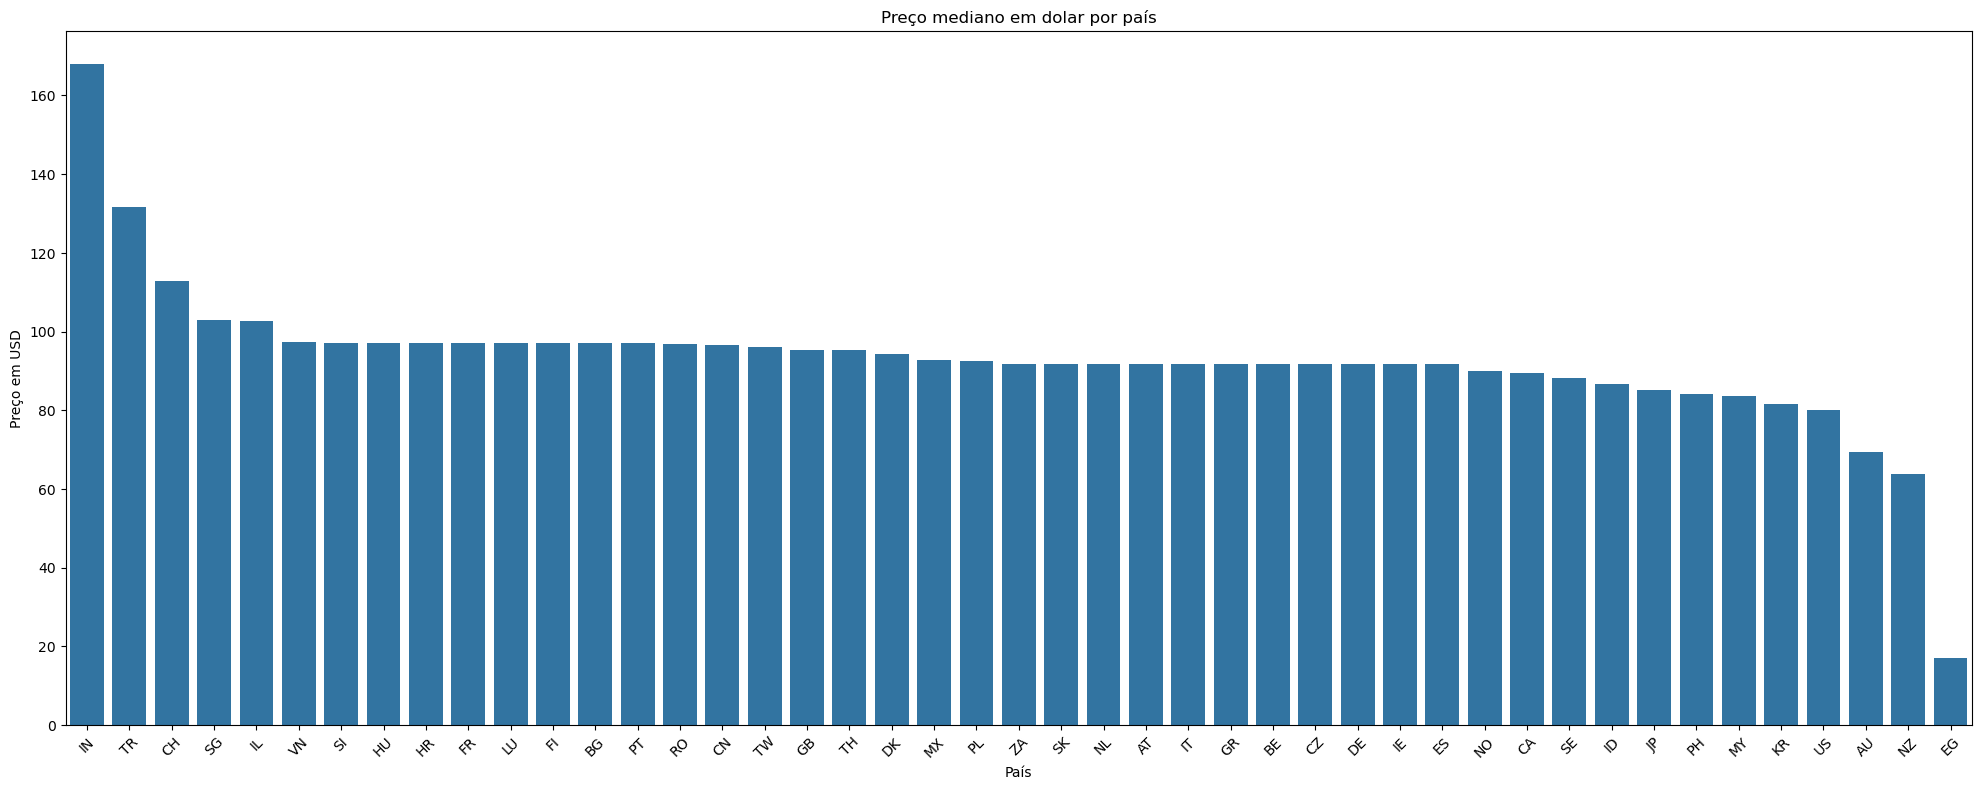

In [127]:
usdp_med = df.groupby('country_code')['price_usd'].median().reset_index().sort_values(by='price_usd', ascending=False)

plt.figure(figsize=(20, 8))
plt.title('Preço mediano em dolar por país')
plt.xlabel('País')
plt.ylabel('Preço em USD')
plt.xticks(rotation=45)
plt.tight_layout()
sns.barplot(data=usdp_med, x='country_code', y='price_usd')
plt.show()

## Gráfico 2 - Preço mediano em dólar de categorias/país

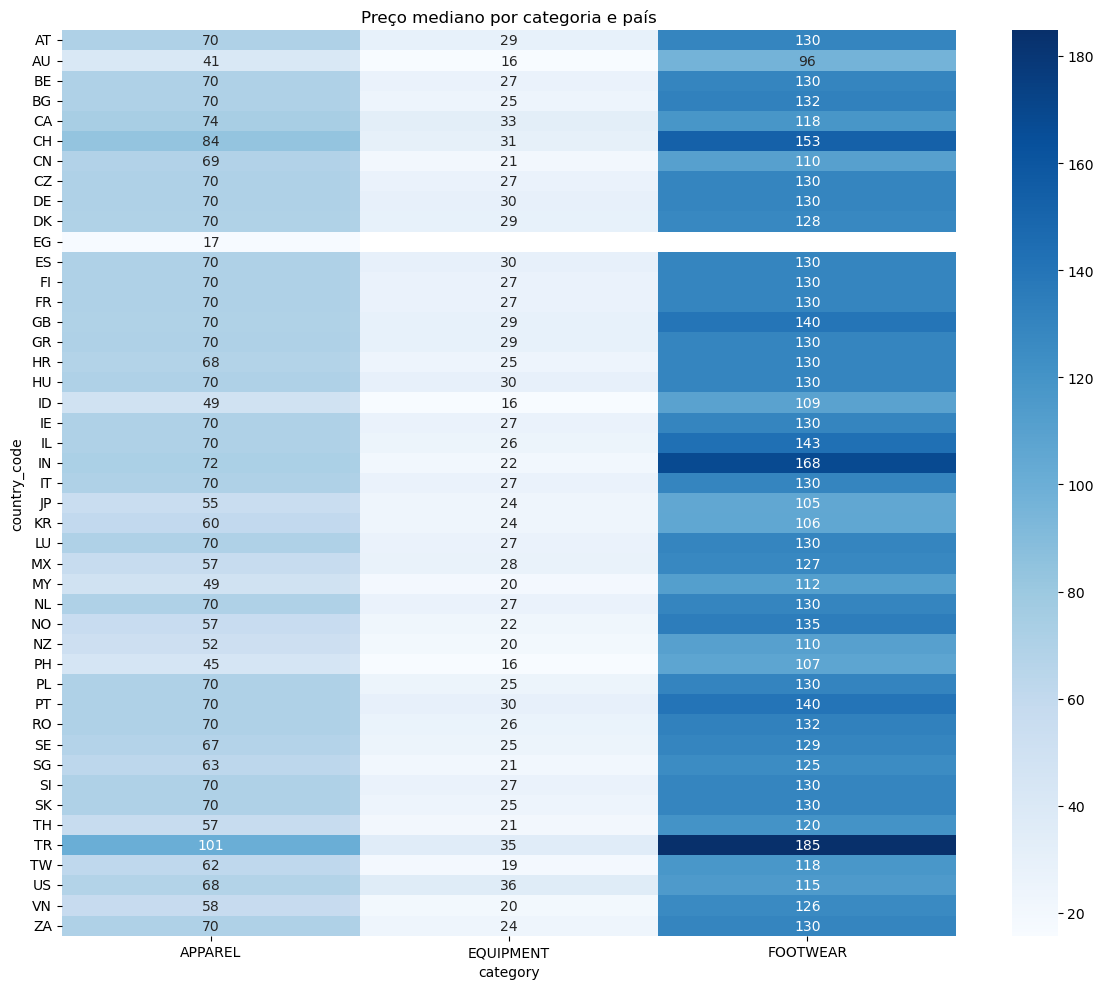

In [ ]:
df_filtrado1 = df[~df['category'].isin(['PHYSICAL_GIFT_CARD', 'DIGITAL_GIFT_CARD'])]

usdp_cat_med = df_filtrado1.groupby(['country_code', 'category'])['price_usd'].median().sort_values(ascending=False).reset_index()

#.pivot: transforma o resultado numa tabela onde as linhas são países e as colunas são categorias
table1 = usdp_cat_med.pivot(index='country_code', columns='category', values='price_usd')

plt.figure(figsize=(12, 10))
sns.heatmap(data=table1, annot=True, fmt='.0f', cmap='Blues')
plt.title('Preço mediano por categoria e país')
plt.tight_layout()
plt.show()

## Gráfico 3 - % mediana de desconto/país

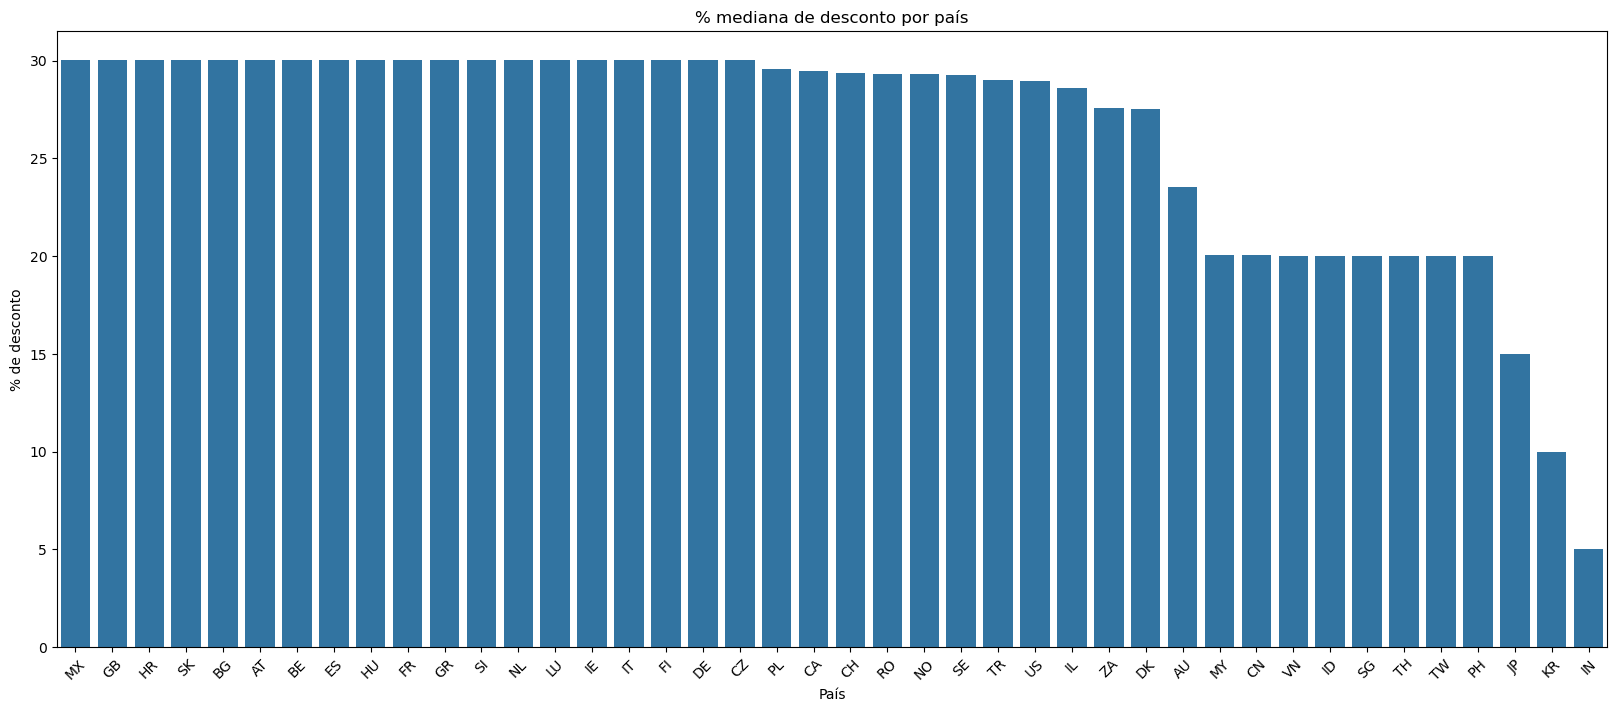

In [129]:
usd_disc_med = df[df['discount_pct'] > 0].groupby('country_code')['discount_pct'].median().sort_values(ascending=False).reset_index()

plt.figure(figsize=(20, 8))
plt.title('% mediana de desconto por país')
plt.xlabel('País')
plt.ylabel('% de desconto')
plt.xticks(rotation=45)
sns.barplot(data=usd_disc_med, x='country_code', y='discount_pct')
plt.show()

## Gráfico 4 - % mediana de desconto de categoria/país

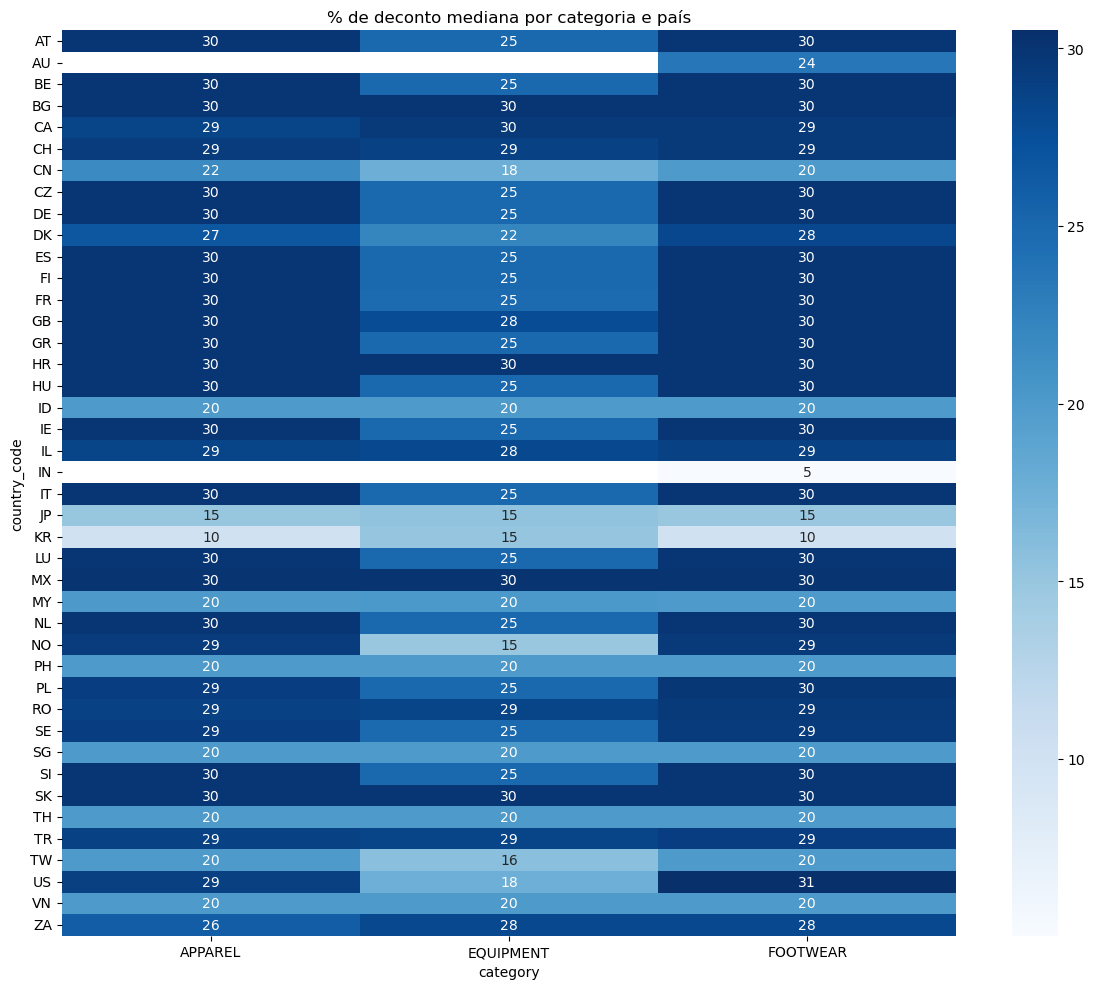

In [136]:
df_filtrado2= df[df['discount_pct'] > 0]

disc_cat_country = df_filtrado2.groupby(['country_code', 'category'])['discount_pct'].median().reset_index()

table2 = disc_cat_country.pivot(index='country_code', columns='category', values='discount_pct')

plt.figure(figsize=(12, 10))
sns.heatmap(data=table2, annot=True, fmt='.0f', cmap='Blues')
plt.title('% de deconto mediana por categoria e país')
plt.tight_layout()
plt.show()

## Gráfico 5 - Desconto vs Preço


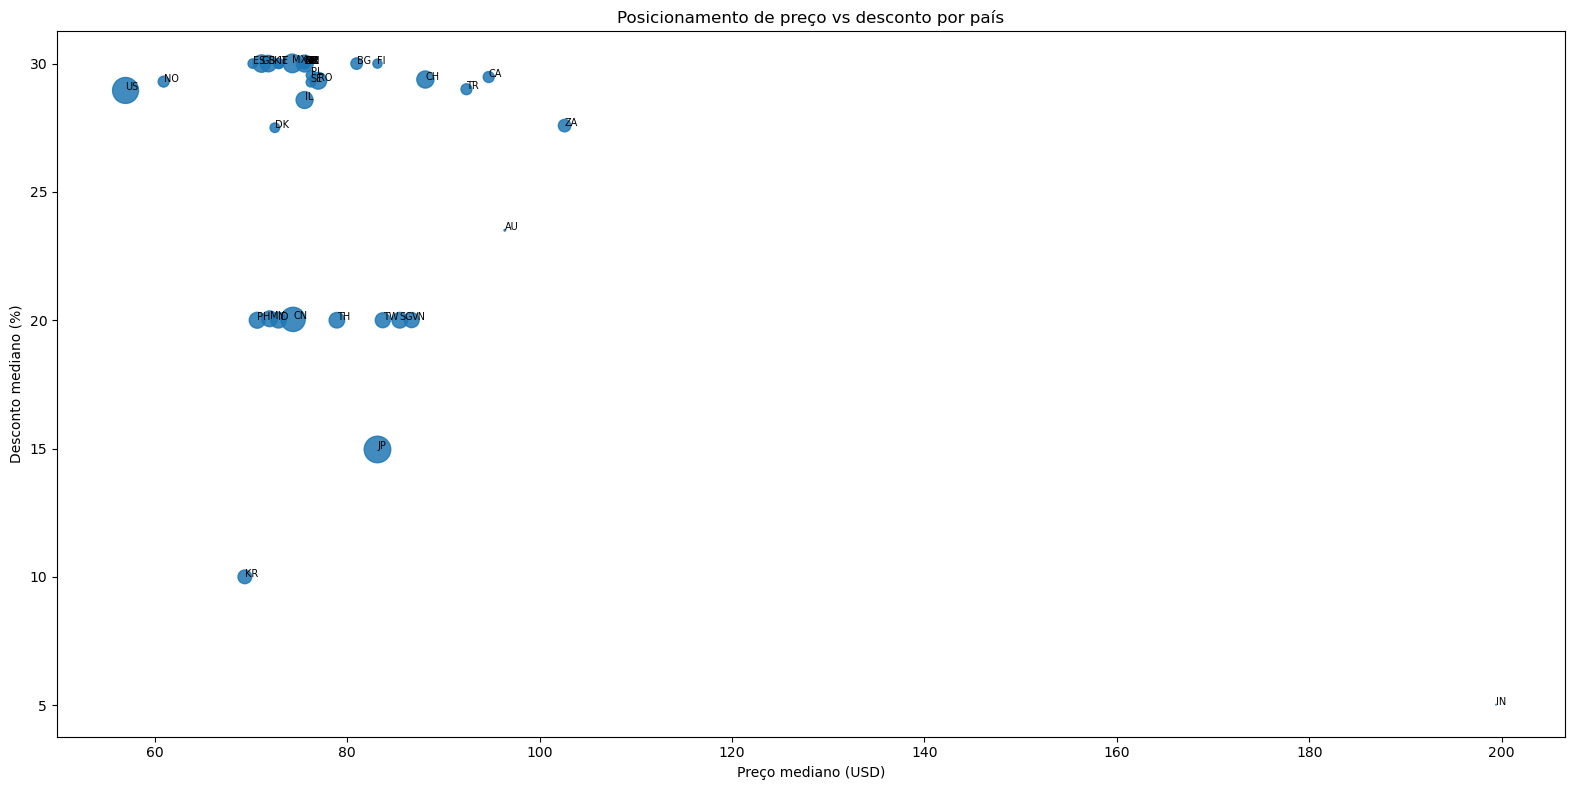

In [162]:
resumo = df[df['discount_pct'] > 0].groupby('country_code').agg(preco=('price_usd', 'median'), desconto=('discount_pct', 'median'), 
    volume=('price_usd', 'count')).reset_index()

plt.figure(figsize=(16, 8))
plt.title('Posicionamento de preço vs desconto por país')
plt.xlabel('Preço mediano (USD)')
plt.ylabel('Desconto mediano (%)')
plt.tight_layout()

plt.scatter(data=resumo, x='preco', y='desconto', s=resumo['volume']/50, alpha=0.85)

for i, row in resumo.iterrows():
    plt.annotate(row['country_code'], (row['preco'], row['desconto']), fontsize=7)

plt.show()

# Conclusão

1. A Nike mantém preços consistentes globalmente, com a maioria dos países entre $80-$100 USD, o que mostra uma estratégia de preço de marca consistente entre mercados.

2. Países que são outliers: Índia, Japão, Coréia do Sul e Egito. Devido a questões de posicionamento estratégico da marca ou somente por baixos descontos.

3. Nossa hipótese foi parcialmente confirmada. Apesar dos dados concentrados, encontramos outliers relevantes como a Índia $167 e o Egito $16, que mostram estratégias bem distintas dos demais países.